<a href="https://colab.research.google.com/github/Mouni178/Python-Programming/blob/main/ML2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay

In [3]:
#Load Dataset
df=pd.read_csv("/content/titanic.csv")
print("Shape of Database:",df.shape)
df.head()

Shape of Database: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
#Basic Exploratory Data Analysis
df.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


Overall sut=rvival rate:38.38%


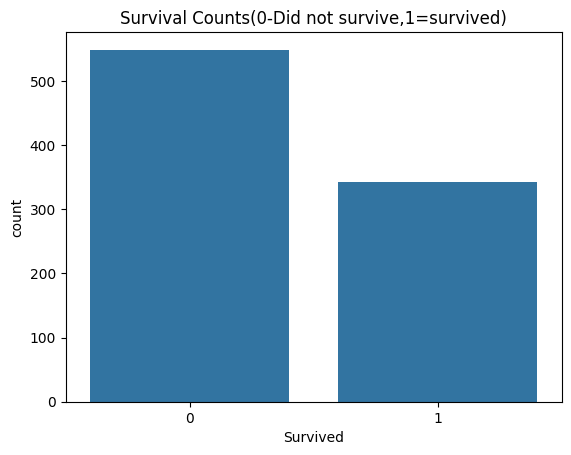

In [8]:
#Overall survival rate
survival_rate=df["Survived"].mean()
print(f"Overall sut=rvival rate:{survival_rate:.2%}")
sns.countplot(data=df,x="Survived")
plt.title("Survival Counts(0-Did not survive,1=survived)")
plt.show()

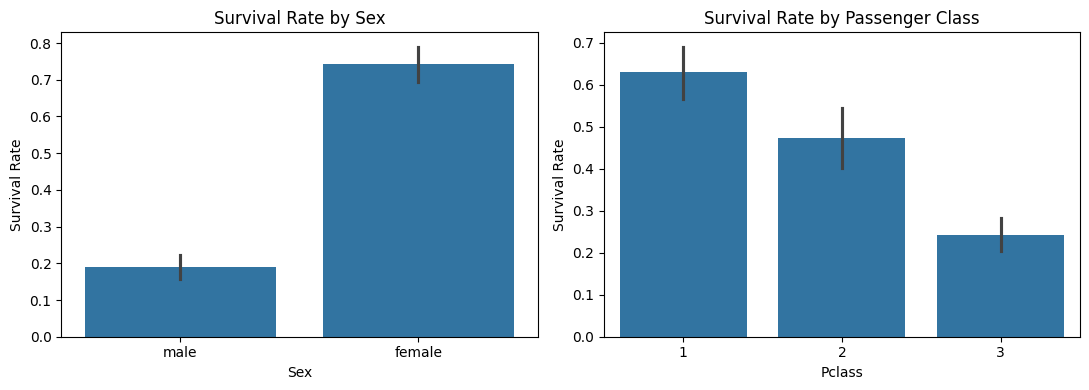

In [9]:
# Survival rate by sex and passenger class — two of the strongest predictors
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(data=df, x="Sex", y="Survived", ax=axes[0])
axes[0].set_title("Survival Rate by Sex")
axes[0].set_ylabel("Survival Rate")

sns.barplot(data=df, x="Pclass", y="Survived", ax=axes[1])
axes[1].set_title("Survival Rate by Passenger Class")
axes[1].set_ylabel("Survival Rate")

plt.tight_layout()
plt.show()

In [10]:
#Data Cleaning an Feature preperation
data = df.copy()
# Drop columns not used in this simple model
data = data.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
# Fill missing values
data["Age"] = data["Age"].fillna(data["Age"].median())
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])
# Feature engineering: family size
data["FamilySize"] = data["SibSp"] + data["Parch"] + 1
# Encode categorical variables
data["Sex"] = data["Sex"].map({"male": 0, "female": 1})
data = pd.get_dummies(data, columns=["Embarked"], drop_first=True)
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,2,False,True
1,1,1,1,38.0,1,0,71.2833,2,False,False
2,1,3,1,26.0,0,0,7.9250,1,False,True
3,1,1,1,35.0,1,0,53.1000,2,False,True
4,0,3,0,35.0,0,0,8.0500,1,False,True


In [11]:
#Confirm no missing values remain
data.isnull().sum().sum()

np.int64(0)

In [12]:
#split features and target,traintestsplit
X = data.drop(columns=["Survived"])
y = data["Survived"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (712, 9)
Test set size: (179, 9)


In [13]:
# Scale numeric features (helps Logistic Regression converge and perform better)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
#train a model-Logistic regression
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [15]:
#evaluate the model
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.2%}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Did not survive", "Survived"]))

Test Accuracy: 80.45%

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



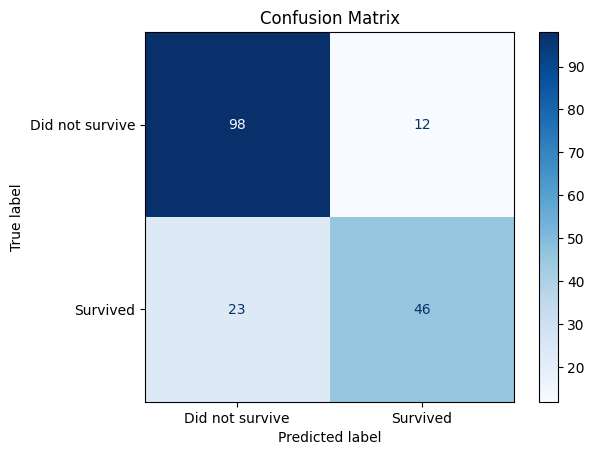

In [16]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Did not survive", "Survived"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

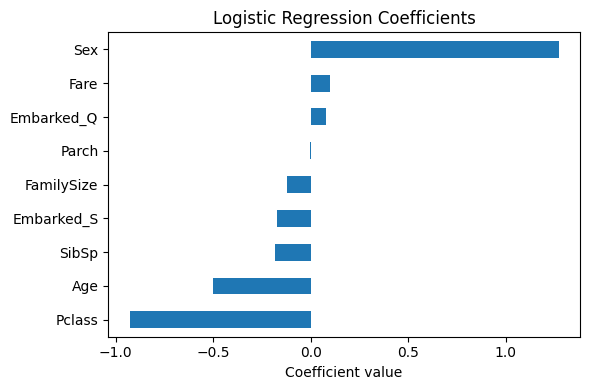

In [17]:
# Which features mattered most? (Logistic Regression coefficients)
coeffs = pd.Series(model.coef_[0], index=X.columns).sort_values()
coeffs.plot(kind="barh", figsize=(6, 4), title="Logistic Regression Coefficients")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()

In [18]:
new_passenger = pd.DataFrame({
    "Pclass": [1],
    "Sex": [1],       # female
    "Age": [28],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [80],
    "FamilySize": [1],
    "Embarked_Q": [0],
    "Embarked_S": [1],
})

# Ensure column order matches training data
new_passenger = new_passenger[X.columns]

new_passenger_scaled = scaler.transform(new_passenger)
prediction = model.predict(new_passenger_scaled)[0]
probability = model.predict_proba(new_passenger_scaled)[0][1]

print("Predicted survival:", "Survived" if prediction == 1 else "Did not survive")
print(f"Predicted probability of survival: {probability:.2%}")

Predicted survival: Survived
Predicted probability of survival: 93.67%


In [19]:
#train a model-Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [20]:
#Evaluate the model
acc = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {acc:.2%}")

print("\nClassification Report:")

print(classification_report(
    y_test,
    y_pred,
    target_names=["Did not survive", "Survived"]
))

Test Accuracy: 79.33%

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.82      0.85      0.83       110
       Survived       0.74      0.71      0.73        69

       accuracy                           0.79       179
      macro avg       0.78      0.78      0.78       179
   weighted avg       0.79      0.79      0.79       179



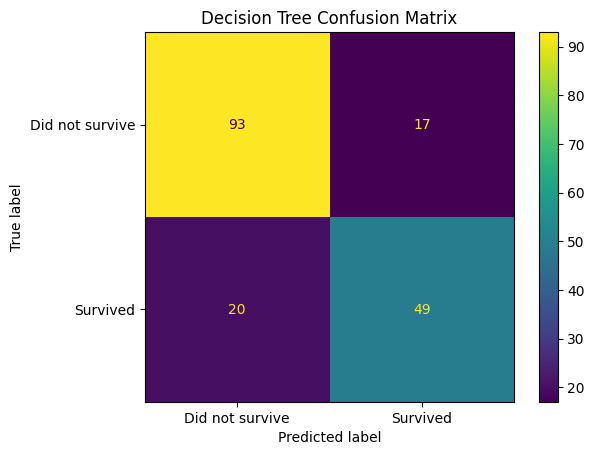

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did not survive", "Survived"]
)

disp.plot()

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [22]:
#Which features mattered most?
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values()

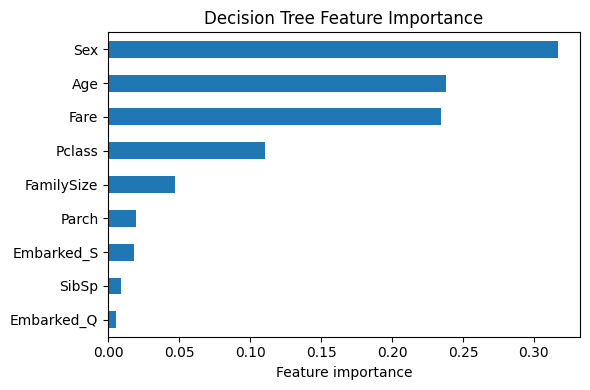

In [23]:
importances.plot(
    kind="barh",
    figsize=(6, 4),
    title="Decision Tree Feature Importance"
)

plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()